
# Proyecto Final: Telecomunicaciones — Identificar operadores ineficaces (CallMeMaybe)

**Objetivo:** identificar operadores menos eficaces para apoyar a supervisores con información accionable.

Un operador se considera **ineficaz** si:
- Tiene muchas **llamadas entrantes perdidas** (internas y externas).
- Presenta **tiempos de espera altos** en llamadas entrantes.
- Si realiza llamadas salientes (según el histórico), un volumen **muy bajo** también puede indicar ineficacia.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ruta simple (asumiendo notebook dentro de /notebooks)
calls = pd.read_csv("../data/telecom_dataset_new.csv")
clients = pd.read_csv("../data/telecom_clients.csv")

calls.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [2]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16



## 1) Exploración inicial (EDA)

Preguntas que respondemos aquí:
- ¿Cuántas llamadas entrantes vs salientes hay?
- ¿Qué proporción son internas vs externas?
- ¿Cómo se distribuye la duración de llamadas?
- ¿Hay valores nulos o tipos incorrectos?

Hallazgos rápidos:
- `operator_id` tiene nulos (llamadas sin operador asignado). Para medir desempeño por operador, solo usamos filas con `operator_id`.
- `internal` tiene pocos nulos; los marcamos como `"unknown"` para no perder registros en gráficos.


In [3]:
# Tamaño y columnas
print("calls shape:", calls.shape)
print("clients shape:", clients.shape)

print("\nColumnas calls:", list(calls.columns))
print("Columnas clients:", list(clients.columns))

calls shape: (53902, 9)
clients shape: (732, 3)

Columnas calls: ['user_id', 'date', 'direction', 'internal', 'operator_id', 'is_missed_call', 'calls_count', 'call_duration', 'total_call_duration']
Columnas clients: ['user_id', 'tariff_plan', 'date_start']


In [4]:
# Tipos y nulos
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [5]:
calls.isna().sum().sort_values(ascending=False)

operator_id            8172
internal                117
user_id                   0
direction                 0
date                      0
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [6]:
# Convertir fecha
calls["date"] = pd.to_datetime(calls["date"], errors="coerce")

# internal: reemplazar nulos por "unknown" para no perder registros en gráficos
calls["internal"] = calls["internal"].fillna("unknown")

# Checks básicos
print("Rango fechas:", calls["date"].min(), "a", calls["date"].max())
calls["internal"].value_counts(dropna=False)

Rango fechas: 2019-08-02 00:00:00+03:00 a 2019-11-28 00:00:00+03:00


internal
False      47621
True        6164
unknown      117
Name: count, dtype: int64

In [7]:
# Conteo de llamadas por dirección
calls["direction"].value_counts()

direction
out    31917
in     21985
Name: count, dtype: int64

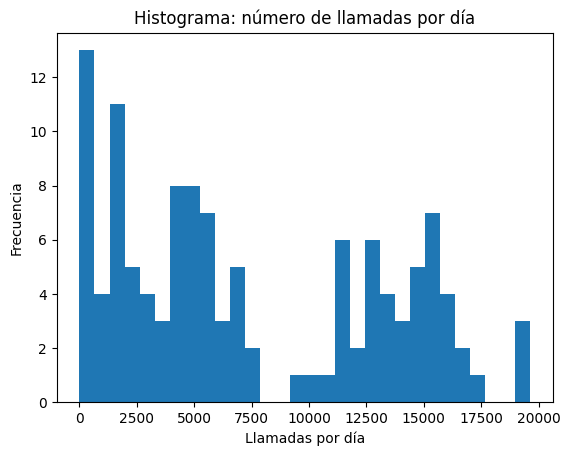

In [8]:
# Histograma: número de llamadas por día (sumando calls_count)
calls["day"] = calls["date"].dt.date
calls_per_day = calls.groupby("day")["calls_count"].sum()

calls_per_day.plot(kind="hist", bins=30)
plt.title("Histograma: número de llamadas por día")
plt.xlabel("Llamadas por día")
plt.ylabel("Frecuencia")
plt.show()

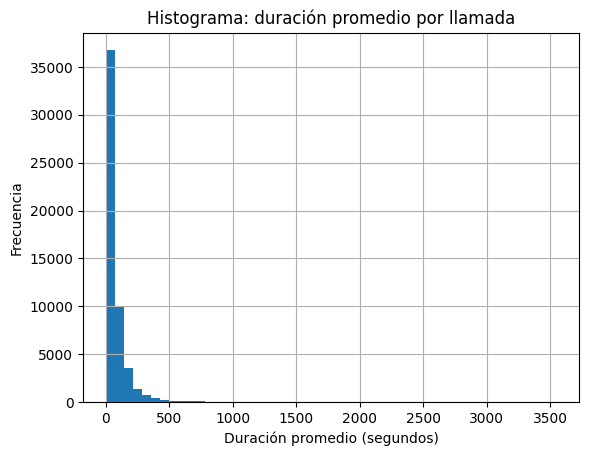

In [9]:
# Histograma: duración promedio por llamada (segundos)
calls = calls[calls["calls_count"] > 0].copy()
calls["avg_call_duration"] = calls["call_duration"] / calls["calls_count"]

calls["avg_call_duration"].hist(bins=50)
plt.title("Histograma: duración promedio por llamada")
plt.xlabel("Duración promedio (segundos)")
plt.ylabel("Frecuencia")
plt.show()

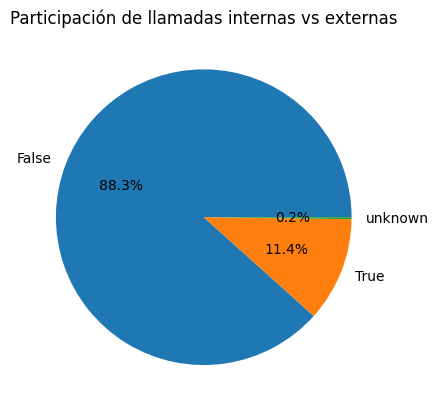

In [10]:
# Pie chart: internas vs externas (incluye "unknown")
calls["internal"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Participación de llamadas internas vs externas")
plt.ylabel("")
plt.show()

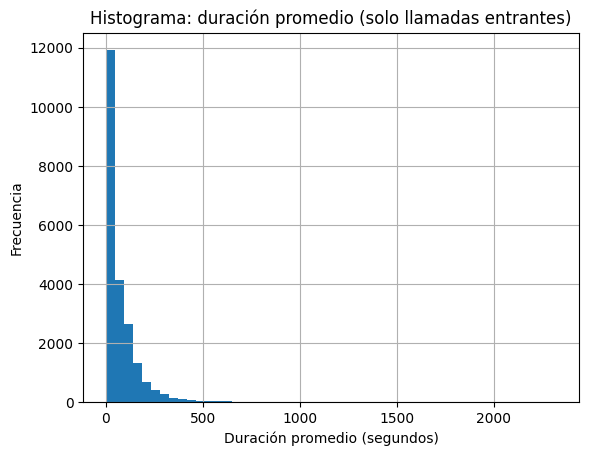

In [11]:
# (Filtro simple) Ejemplo: histograma solo de entrantes
calls_in = calls[calls["direction"] == "in"].copy()
calls_in["avg_call_duration"] = calls_in["call_duration"] / calls_in["calls_count"]

calls_in["avg_call_duration"].hist(bins=50)
plt.title("Histograma: duración promedio (solo llamadas entrantes)")
plt.xlabel("Duración promedio (segundos)")
plt.ylabel("Frecuencia")
plt.show()

##  Preparación de métricas (duración y espera)

In [12]:
# Duración total promedio por llamada y espera promedio por llamada
calls["avg_total_duration"] = calls["total_call_duration"] / calls["calls_count"]
calls["avg_wait_time"] = (calls["avg_total_duration"] - calls["avg_call_duration"]).clip(lower=0)

calls[["avg_call_duration","avg_total_duration","avg_wait_time"]].describe()

,avg_call_duration,avg_total_duration,avg_wait_time
count,53902.000000,53902.000000,53902.000000
mean,66.651534,83.495437,16.843903
std,124.873511,124.448431,13.983057
min,0.000000,0.000000,0.000000
25%,0.000000,19.800000,8.000000
50%,23.954522,45.000000,14.543860
75%,90.000000,105.250000,22.289855
max,3550.000000,3609.000000,465.000000



##  Métricas y criterio de ineficacia

Creamos métricas por operador:

- **incoming_calls**: total de llamadas entrantes (ponderado por `calls_count`)
- **incoming_missed_calls**: total de llamadas entrantes perdidas (ponderado)
- **missed_rate_in**: tasa de perdidas entrantes = missed / incoming
- **avg_wait_time_in**: tiempo promedio de espera en entrantes (segundos)
- **outgoing_calls**: total de llamadas salientes (ponderado)

**Criterio (simple y defendible por percentiles):**
- *Alta tasa de perdidas*: `missed_rate_in` >= percentil 90 (**0.0354**)
- *Alta espera*: `avg_wait_time_in` >= percentil 90 (**33.99 s**)
- *Bajas salientes*: solo para operadores con salientes (`outgoing_calls` > 0), `outgoing_calls` <= percentil 10 (**4**)

Con este criterio, se marcaron:
- Operadores ineficaces: **197** (26.1%)
- Operadores no ineficaces: **557**


In [13]:
# Filtrar solo llamadas con operador para KPIs por operador
calls_ops = calls[calls["operator_id"].notna()].copy()
calls_ops["operator_id"] = calls_ops["operator_id"].astype(int)

# Entrantes
incoming = calls_ops[calls_ops["direction"] == "in"].copy()
in_total = incoming.groupby("operator_id")["calls_count"].sum()
in_missed = incoming[incoming["is_missed_call"] == True].groupby("operator_id")["calls_count"].sum()

# Espera ponderada por calls_count
in_wait_sum = (incoming["avg_wait_time"] * incoming["calls_count"]).groupby(incoming["operator_id"]).sum()
in_wait_avg = in_wait_sum / in_total

# Salientes
outgoing = calls_ops[calls_ops["direction"] == "out"].copy()
out_total = outgoing.groupby("operator_id")["calls_count"].sum()

# Tabla KPI
operators_kpi = pd.DataFrame({
    "incoming_calls": in_total,
    "incoming_missed_calls": in_missed
}).fillna(0)

operators_kpi["missed_rate_in"] = operators_kpi["incoming_missed_calls"] / operators_kpi["incoming_calls"]
operators_kpi["avg_wait_time_in"] = in_wait_avg

operators_kpi = operators_kpi.reset_index()

operators_kpi = operators_kpi.merge(
    out_total.rename("outgoing_calls"),
    on="operator_id",
    how="left"
).fillna({"outgoing_calls": 0})

operators_kpi.head()

,operator_id,incoming_calls,incoming_missed_calls,missed_rate_in,avg_wait_time_in,outgoing_calls
0,879896,60,0.0,0.0,10.316667,1071.0
1,879898,118,0.0,0.0,15.296610,7856.0
2,880020,8,0.0,0.0,7.250000,46.0
3,880022,8,0.0,0.0,14.000000,211.0
4,880026,25,0.0,0.0,6.000000,2414.0


In [14]:
operators_kpi.describe()

,operator_id,incoming_calls,incoming_missed_calls,missed_rate_in,avg_wait_time_in,outgoing_calls
count,754.000000,754.000000,754.000000,754.000000,754.000000,754.000000
mean,923704.400531,137.527851,1.340849,0.017169,17.475979,503.641910
std,22646.733795,394.104950,4.199444,0.066000,12.198126,3474.669443
min,879896.000000,1.000000,0.000000,0.000000,0.681614,0.000000
25%,905153.000000,4.000000,0.000000,0.000000,9.375132,0.000000
50%,924580.000000,19.000000,0.000000,0.000000,14.395385,25.000000
75%,940457.500000,83.750000,1.000000,0.006536,21.868793,251.250000
max,973286.000000,5221.000000,55.000000,1.000000,115.500000,64897.000000


In [15]:
# Criterio p90/p90 + p10 (solo si tiene salientes)
thr_missed = operators_kpi["missed_rate_in"].quantile(0.90)
thr_wait = operators_kpi["avg_wait_time_in"].quantile(0.90)

does_out = operators_kpi["outgoing_calls"] > 0
thr_out_low = operators_kpi.loc[does_out, "outgoing_calls"].quantile(0.10) if does_out.any() else 0

operators_kpi["ineffective"] = (
    (operators_kpi["missed_rate_in"] >= thr_missed) |
    (operators_kpi["avg_wait_time_in"] >= thr_wait) |
    (does_out & (operators_kpi["outgoing_calls"] <= thr_out_low))
)

operators_kpi["ineffective"].value_counts()

ineffective
False    557
True     197
Name: count, dtype: int64

In [16]:
# Lista de ineficaces (top 20)
ineff = operators_kpi[operators_kpi["ineffective"] == True].copy()
ineff.sort_values(["missed_rate_in","avg_wait_time_in"], ascending=False).head(20)

,operator_id,incoming_calls,incoming_missed_calls,missed_rate_in,avg_wait_time_in,outgoing_calls,ineffective
641,948756,1,1.0,1.000000,8.000000,175.0,True
185,904344,7,6.0,0.857143,13.285714,5.0,True
287,913886,2,1.0,0.500000,13.500000,0.0,True
210,906392,19,7.0,0.368421,13.421053,61.0,True
467,934098,6,2.0,0.333333,26.500000,0.0,True
497,937432,3,1.0,0.333333,12.000000,25.0,True
698,957922,3,1.0,0.333333,8.666667,20.0,True
220,906412,26,7.0,0.269231,15.384615,328.0,True
109,897872,4,1.0,0.250000,20.500000,53.0,True
383,924936,8,2.0,0.250000,19.250000,0.0,True



##  Pruebas de hipótesis (validación estadística)

Usamos **Mann–Whitney U** (no paramétrica) para comparar grupos:
- Grupo A: operadores **ineficaces**
- Grupo B: operadores **no ineficaces**

### Hipótesis 1
- H0: `missed_rate_in` es igual en ambos grupos.
- H1: `missed_rate_in` es mayor en el grupo ineficaz.

Resultado (alternativa='greater'):
- p-value = **1.38e-12**
- promedio ineficaces = **0.0555**
- promedio no ineficaces = **0.0036**

### Hipótesis 2
- H0: `avg_wait_time_in` es igual en ambos grupos.
- H1: `avg_wait_time_in` es mayor en el grupo ineficaz.

Resultado:
- p-value = **4.34e-23**
- promedio ineficaces = **26.94 s**
- promedio no ineficaces = **14.13 s**

**Interpretación (nivel proyecto):** ambos p-values < 0.05, por lo que rechazamos H0 en los dos casos.


In [17]:
from scipy.stats import mannwhitneyu

# Hipótesis 1: missed_rate_in mayor en ineficaces
bad = operators_kpi.loc[operators_kpi["ineffective"] == True, "missed_rate_in"].dropna()
good = operators_kpi.loc[operators_kpi["ineffective"] == False, "missed_rate_in"].dropna()

stat1, p1 = mannwhitneyu(bad, good, alternative="greater")
print("Hipótesis 1 - missed_rate_in")
print("p-value:", p1)
print("promedio ineficaces:", bad.mean())
print("promedio no ineficaces:", good.mean())

# Hipótesis 2: wait_time mayor en ineficaces
bad_w = operators_kpi.loc[operators_kpi["ineffective"] == True, "avg_wait_time_in"].dropna()
good_w = operators_kpi.loc[operators_kpi["ineffective"] == False, "avg_wait_time_in"].dropna()

stat2, p2 = mannwhitneyu(bad_w, good_w, alternative="greater")
print("\nHipótesis 2 - avg_wait_time_in")
print("p-value:", p2)
print("promedio ineficaces:", bad_w.mean())
print("promedio no ineficaces:", good_w.mean())

Hipótesis 1 - missed_rate_in
p-value: 1.380208098064639e-12
promedio ineficaces: 0.05553721729184198
promedio no ineficaces: 0.003599030349943843

Hipótesis 2 - avg_wait_time_in
p-value: 4.344326557778522e-23
promedio ineficaces: 26.935529005940744
promedio no ineficaces: 14.130321612145574



## 4) Conclusiones y recomendaciones

**Conclusiones**
- Se identificaron **197** operadores ineficaces (26.1%) con base en percentiles (p90/p90/p10) en perdidas y espera.
- Los operadores ineficaces muestran **mayor tasa de llamadas perdidas** y **mayor tiempo de espera**; la diferencia es estadísticamente significativa (Mann–Whitney).

**Recomendaciones**
- Priorizar coaching/entrenamiento y monitoreo para operadores con:
  - `missed_rate_in` alto (top 10%)
  - `avg_wait_time_in` alto (top 10%)
- Para operadores que sí realizan salientes, revisar planificación/carga de trabajo si `outgoing_calls` está en el bottom 10%.
- Complementar con análisis por cliente (`tariff_plan`) solo como contexto, no como criterio principal.

**Outputs**
- `outputs/metricas_operadores.csv`
- `outputs/operadores_ineficaces.csv`


In [18]:
# Guardar outputs
from pathlib import Path
Path("../outputs").mkdir(exist_ok=True)

operators_kpi.to_csv("../outputs/metricas_operadores.csv", index=False)
ineff.to_csv("../outputs/operadores_ineficaces.csv", index=False)

print("Archivos guardados en outputs/")

Archivos guardados en outputs/
